# End-to-End Autoencoder Anomaly Detection with PyTorch

This notebook demonstrates a complete anomaly detection pipeline using:
- Robust statistical filtering (Mahalanobis distance)
- PyTorch autoencoder for reconstruction
- Feature-level attribution via reconstruction error

**Features modeled:**
- f1: Trend strength (e.g., moving-average ratio)
- f2: Momentum (e.g., MACD-like signal)
- f3: Volatility (e.g., ATR-like proxy)

## 1. Imports

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.covariance import MinCovDet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.9.1
Device: cpu


## 2. Generate Synthetic Normal Training Data

We generate correlated multivariate normal data to define the baseline "normal" regime.

In [42]:
n_train = 2000

# Define mean vector
mean = np.array([0.0, 0.0, 0.0])

# Define covariance matrix (correlated features)
cov = np.array([
    [1.0,  0.8,  0.4],   # f1 correlated with f2, f3
    [0.8,  1.0,  0.5],
    [0.4,  0.5,  1.0]
])

# Generate training data
X_train = np.random.multivariate_normal(mean, cov, n_train)

print(f"Training data shape: {X_train.shape}")
print(f"\nTraining data statistics:")
print(pd.DataFrame(X_train, columns=['trend', 'momentum', 'volatility']).describe())

Training data shape: (2000, 3)

Training data statistics:
             trend     momentum   volatility
count  2000.000000  2000.000000  2000.000000
mean      0.007032    -0.006718     0.029799
std       1.021869     1.002089     0.978638
min      -3.725551    -4.604472    -3.566489
25%      -0.689023    -0.687508    -0.638864
50%       0.017072     0.019422     0.067790
75%       0.672919     0.652568     0.700856
max       3.313965     3.307023     3.465171


### Visualize Training Data Correlations

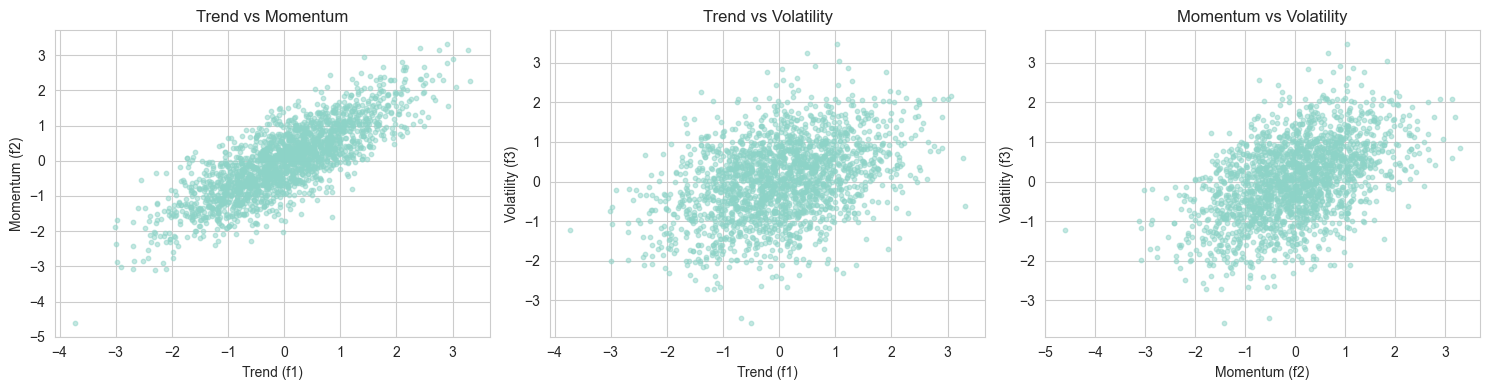

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Scatter plots of feature pairs
axes[0].scatter(X_train[:, 0], X_train[:, 1], alpha=0.5, s=10)
axes[0].set_xlabel('Trend (f1)')
axes[0].set_ylabel('Momentum (f2)')
axes[0].set_title('Trend vs Momentum')

axes[1].scatter(X_train[:, 0], X_train[:, 2], alpha=0.5, s=10)
axes[1].set_xlabel('Trend (f1)')
axes[1].set_ylabel('Volatility (f3)')
axes[1].set_title('Trend vs Volatility')

axes[2].scatter(X_train[:, 1], X_train[:, 2], alpha=0.5, s=10)
axes[2].set_xlabel('Momentum (f2)')
axes[2].set_ylabel('Volatility (f3)')
axes[2].set_title('Momentum vs Volatility')

plt.tight_layout()
plt.show()

## 3. Normalize Features

Normalization is required for:
- Mahalanobis distance calculation
- Neural network training stability(unsupervised)

In [44]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Mean: {X_train_scaled.mean(axis=0)}")
print(f"Std: {X_train_scaled.std(axis=0)}")

Scaled training data shape: (2000, 3)
Mean: [ 3.05311332e-18  9.92539384e-17 -1.26010313e-17]
Std: [1. 1. 1.]


## 4. Mahalanobis Outlier Detection

Before training the autoencoder, we remove multivariate outliers using a **robust covariance estimator**.

This will help ensure the autoencoder is trained on normal data.

In [45]:
# Fit robust covariance estimator
mcd = MinCovDet().fit(X_train_scaled)

# Calculate Mahalanobis distances
md = mcd.mahalanobis(X_train_scaled)

# Define threshold at 97th percentile
threshold = np.percentile(md, 97)
mask = md < threshold

# Filter training data
X_train_clean = X_train_scaled[mask]

print(f"Training samples before: {len(X_train_scaled)}")
print(f"Training samples after Mahalanobis pruning: {len(X_train_clean)}")
print(f"Samples removed: {len(X_train_scaled) - len(X_train_clean)} ({100 * (1 - len(X_train_clean)/len(X_train_scaled)):.1f}%)")

Training samples before: 2000
Training samples after Mahalanobis pruning: 1940
Samples removed: 60 (3.0%)


### Visualize Mahalanobis Distance Distribution

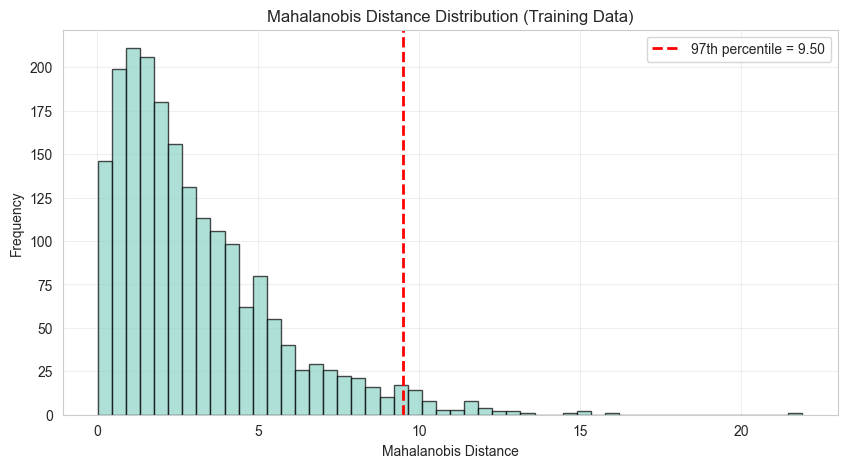

In [46]:
plt.figure(figsize=(10, 5))
plt.hist(md, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'97th percentile = {threshold:.2f}')
plt.xlabel('Mahalanobis Distance')
plt.ylabel('Frequency')
plt.title('Mahalanobis Distance Distribution (Training Data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Define PyTorch Autoencoder

Architecture: 3 → 4 → 2 → 4 → 3
- Input: 3 features
- Encoder: compress to 2-dimensional latent space
- Decoder: reconstruct back to 3 features

In [47]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=4, latent_dim=2):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )
    
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed
    
    def encode(self, x):
        return self.encoder(x)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder(input_dim=3, hidden_dim=4, latent_dim=2).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=3, bias=True)
  )
)

Total parameters: 53


## 6. Train the Autoencoder

In [28]:
# Prepare data
X_train_tensor = torch.FloatTensor(X_train_clean).to(device)
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Define loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 500
losses = []

model.train()
for epoch in range(num_epochs):
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        # Forward pass
        reconstructed = model(batch_x)
        loss = criterion(reconstructed, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}")

print("\nTraining complete!")

Epoch [50/500], Loss: 0.058296
Epoch [100/500], Loss: 0.056459
Epoch [150/500], Loss: 0.056548
Epoch [200/500], Loss: 0.056092
Epoch [250/500], Loss: 0.056479
Epoch [300/500], Loss: 0.056088
Epoch [350/500], Loss: 0.056507
Epoch [400/500], Loss: 0.056235
Epoch [450/500], Loss: 0.056172
Epoch [500/500], Loss: 0.056516

Training complete!


### Visualize Training Loss

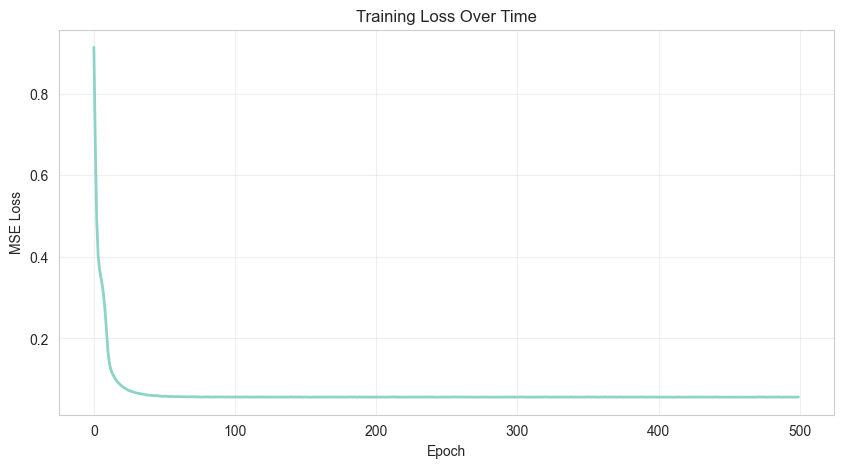

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.show()

## 7. Create Test Data with Anomalies

The test set mixes:
- Normal samples (70%)
- Anomalies (30%) that break correlations or spike volatility

**Note:** In this tutorial, we synthetically create anomalies for demonstration purposes.
In a real-world application, the dataset is split into training and test sets, where the
test set contains naturally occurring data that may or may not include anomalies. The model
learns from the training set and is evaluated on the test set to detect any anomalous patterns.

In [30]:
n_test = 400

# Generate normal test samples
X_test_normal = np.random.multivariate_normal(
    mean, cov, int(n_test * 0.7)
)

# Generate anomalous samples
X_test_anom = np.random.multivariate_normal(
    mean, cov, int(n_test * 0.3)
)

# Inject anomaly behavior
X_test_anom[:, 0] *= 4.0     # extreme trend
X_test_anom[:, 1] *= -3.0    # momentum reversal
X_test_anom[:, 2] += 5.0     # volatility spike

# Combine normal and anomalous samples
X_test = np.vstack([X_test_normal, X_test_anom])

# Labels for inspection only (not used in training)
y_true = np.array(
    [0] * len(X_test_normal) +
    [1] * len(X_test_anom)
)

# Scale test data using training scaler
X_test_scaled = scaler.transform(X_test)

print(f"Test data shape: {X_test_scaled.shape}")
print(f"Normal samples: {sum(y_true == 0)}")
print(f"Anomalous samples: {sum(y_true == 1)}")

Test data shape: (400, 3)
Normal samples: 280
Anomalous samples: 120


### Visualize Test Data Distribution

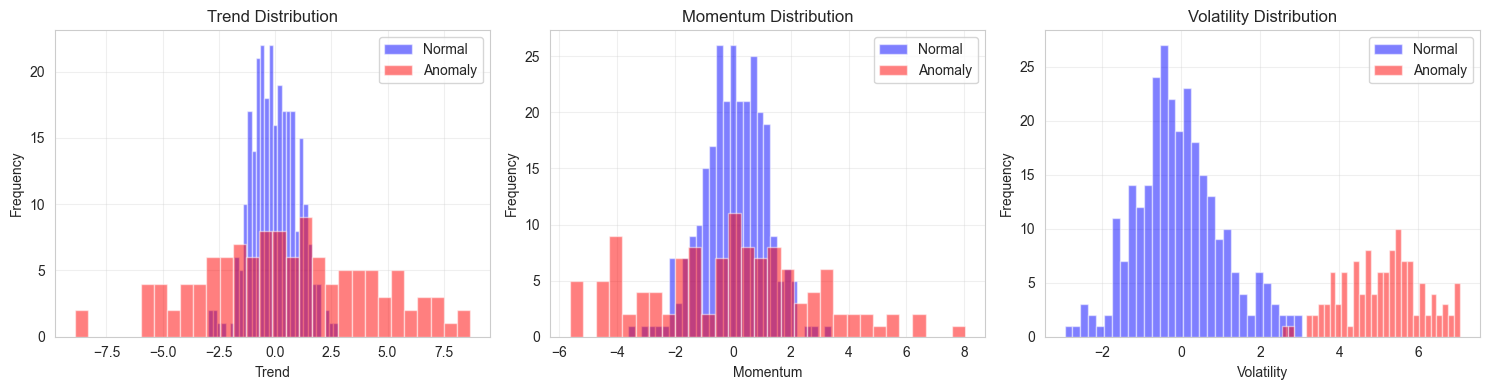

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
feature_names = ['Trend', 'Momentum', 'Volatility']

for i, (ax, name) in enumerate(zip(axes, feature_names)):
    ax.hist(X_test_scaled[y_true == 0, i], bins=30, alpha=0.5, label='Normal', color='blue')
    ax.hist(X_test_scaled[y_true == 1, i], bins=30, alpha=0.5, label='Anomaly', color='red')
    ax.set_xlabel(name)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{name} Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Reconstruction & MSE Anomaly Score

Anomaly score = **mean squared reconstruction error per sample**

In [32]:
# Set model to evaluation mode
model.eval()

# Get reconstructions
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
    X_recon_tensor = model(X_test_tensor)
    X_recon = X_recon_tensor.cpu().numpy()

# Calculate per-sample MSE
mse = np.mean((X_test_scaled - X_recon) ** 2, axis=1)

print(f"Reconstruction MSE statistics:")
print(f"Min: {mse.min():.6f}")
print(f"Max: {mse.max():.6f}")
print(f"Mean: {mse.mean():.6f}")
print(f"Median: {np.median(mse):.6f}")

Reconstruction MSE statistics:
Min: 0.000015
Max: 44.226147
Mean: 2.376116
Median: 0.067918


## 9. Unsupervised Anomaly Threshold

Threshold is derived from the **training reconstruction-error distribution**

In [33]:
# Get training reconstruction errors
with torch.no_grad():
    train_recon_tensor = model(X_train_tensor)
    train_recon = train_recon_tensor.cpu().numpy()

train_mse = np.mean((X_train_clean - train_recon) ** 2, axis=1)

# Set threshold at 99th percentile of training errors
anomaly_threshold = np.percentile(train_mse, 99)

# Classify test samples
pred_anomaly = mse > anomaly_threshold

print(f"Anomaly threshold (99th percentile): {anomaly_threshold:.6f}")
print(f"\nPredicted anomalies: {sum(pred_anomaly)} / {len(pred_anomaly)}")
print(f"True anomalies: {sum(y_true)} / {len(y_true)}")

Anomaly threshold (99th percentile): 0.342937

Predicted anomalies: 123 / 400
True anomalies: 120 / 400


### Visualize Reconstruction Error Distribution

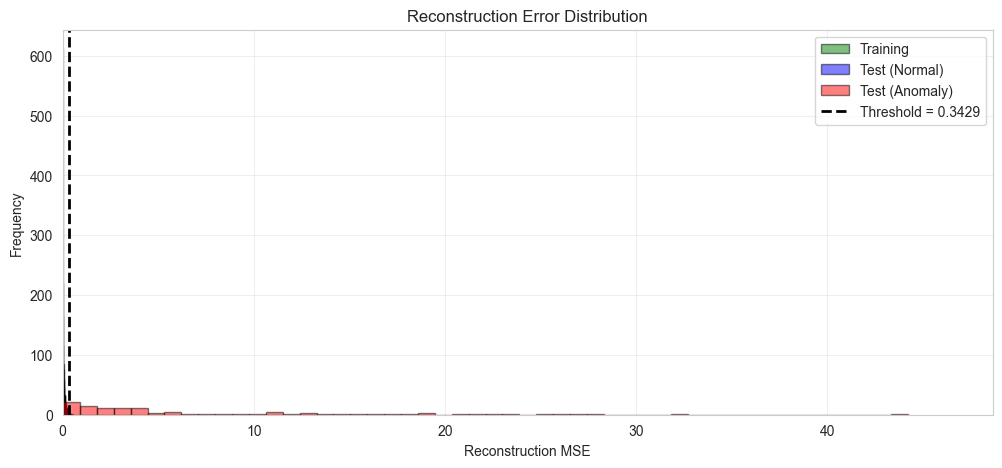

In [34]:
plt.figure(figsize=(12, 5))

# Plot training errors
plt.hist(train_mse, bins=50, alpha=0.5, label='Training', color='green', edgecolor='black')

# Plot test errors by true label
plt.hist(mse[y_true == 0], bins=50, alpha=0.5, label='Test (Normal)', color='blue', edgecolor='black')
plt.hist(mse[y_true == 1], bins=50, alpha=0.5, label='Test (Anomaly)', color='red', edgecolor='black')

# Add threshold line
plt.axvline(anomaly_threshold, color='black', linestyle='--', linewidth=2, 
            label=f'Threshold = {anomaly_threshold:.4f}')

plt.xlabel('Reconstruction MSE')
plt.ylabel('Frequency')
plt.title('Reconstruction Error Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, max(mse.max(), train_mse.max()) * 1.1)
plt.show()

### Evaluate Detection Performance

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Classification metrics
print("Classification Report:")
print(classification_report(y_true, pred_anomaly, target_names=['Normal', 'Anomaly']))

# Confusion matrix
cm = confusion_matrix(y_true, pred_anomaly)
print("\nConfusion Matrix:")
print(cm)

# ROC AUC
auc_score = roc_auc_score(y_true, mse)
print(f"\nROC AUC Score: {auc_score:.4f}")

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.98       280
     Anomaly       0.93      0.96      0.95       120

    accuracy                           0.97       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.97      0.97      0.97       400


Confusion Matrix:
[[272   8]
 [  5 115]]

ROC AUC Score: 0.9922


### ROC Curve

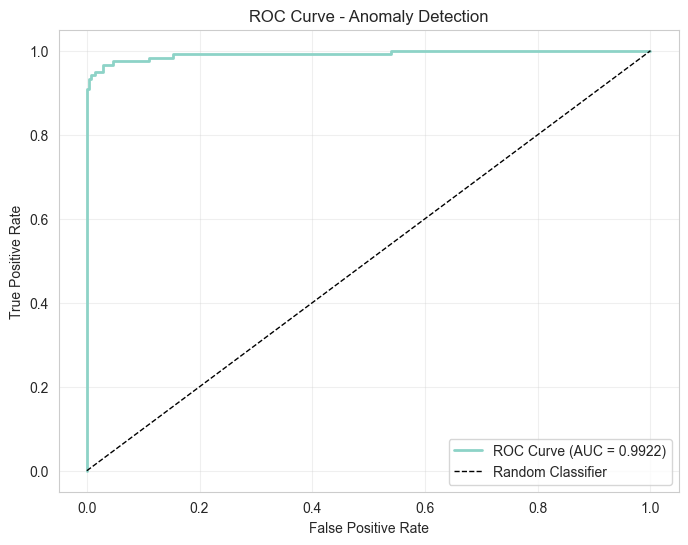

In [36]:
fpr, tpr, thresholds = roc_curve(y_true, mse)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Anomaly Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Feature Attribution

Feature-specific reconstruction error provides the **meaningful attribution**

In [37]:
# Calculate feature-specific squared errors
feature_errors = (X_test_scaled - X_recon) ** 2
feature_names = ["trend", "momentum", "volatility"]

# Get top 5 anomalies
top_idx = np.argsort(mse)[-5:]

print("Top 5 Anomalies - Feature Attribution:\n")
print("=" * 70)

for i in top_idx:
    contrib = dict(zip(feature_names, feature_errors[i]))
    total_error = sum(contrib.values())
    
    print(f"\nSample {i} (True label: {'Anomaly' if y_true[i] == 1 else 'Normal'})")
    print(f"Total Reconstruction MSE: {mse[i]:.6f}")
    print(f"\nFeature Contributions:")
    
    for feat, error in sorted(contrib.items(), key=lambda x: x[1], reverse=True):
        pct = 100 * error / total_error
        print(f"  {feat:12s}: {error:.6f} ({pct:5.1f}%)")
    print("-" * 70)

Top 5 Anomalies - Feature Attribution:


Sample 341 (True label: Anomaly)
Total Reconstruction MSE: 26.868558

Feature Contributions:
  trend       : 45.483422 ( 56.4%)
  momentum    : 31.615534 ( 39.2%)
  volatility  : 3.506718 (  4.4%)
----------------------------------------------------------------------

Sample 302 (True label: Anomaly)
Total Reconstruction MSE: 28.029658

Feature Contributions:
  trend       : 48.324280 ( 57.5%)
  momentum    : 31.727508 ( 37.7%)
  volatility  : 4.037186 (  4.8%)
----------------------------------------------------------------------

Sample 339 (True label: Anomaly)
Total Reconstruction MSE: 32.218100

Feature Contributions:
  trend       : 56.453602 ( 58.4%)
  momentum    : 35.133137 ( 36.3%)
  volatility  : 5.067561 (  5.2%)
----------------------------------------------------------------------

Sample 390 (True label: Anomaly)
Total Reconstruction MSE: 32.418350

Feature Contributions:
  trend       : 52.800559 ( 54.3%)
  momentum    : 41.04791

### Visualize Feature Attribution for Top Anomalies

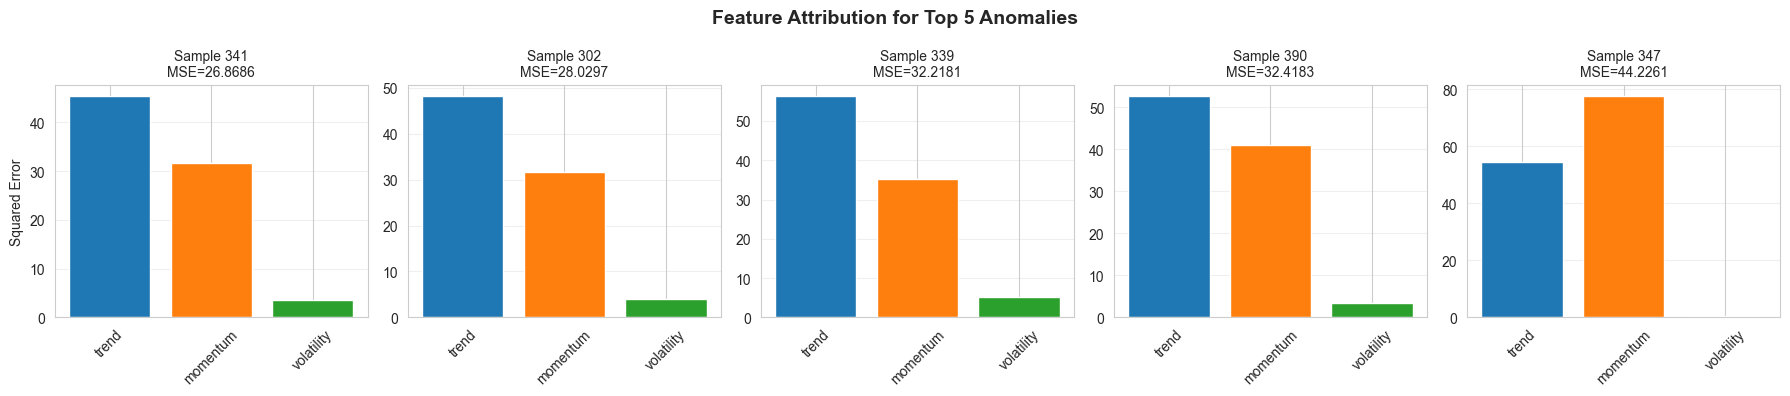

In [38]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax_idx, sample_idx in enumerate(top_idx):
    contrib = feature_errors[sample_idx]
    
    axes[ax_idx].bar(feature_names, contrib, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[ax_idx].set_title(f'Sample {sample_idx}\nMSE={mse[sample_idx]:.4f}', fontsize=10)
    axes[ax_idx].set_ylabel('Squared Error' if ax_idx == 0 else '')
    axes[ax_idx].tick_params(axis='x', rotation=45)
    axes[ax_idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Feature Attribution for Top 5 Anomalies', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Latent Space Visualization

Visualize how normal vs anomalous samples are distributed in the 2D latent space

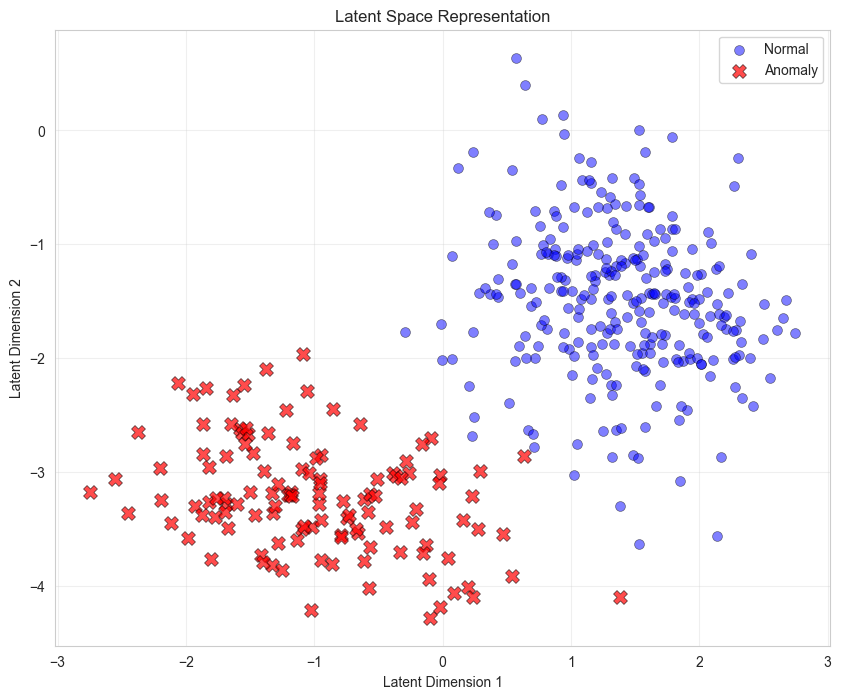

In [39]:
# Encode test data to latent space
with torch.no_grad():
    latent_repr = model.encode(X_test_tensor).cpu().numpy()

# Visualize latent space
plt.figure(figsize=(10, 8))

# Plot normal samples
plt.scatter(latent_repr[y_true == 0, 0], latent_repr[y_true == 0, 1], 
           c='blue', alpha=0.5, s=50, label='Normal', edgecolors='black', linewidth=0.5)

# Plot anomalous samples
plt.scatter(latent_repr[y_true == 1, 0], latent_repr[y_true == 1, 1], 
           c='red', alpha=0.7, s=100, label='Anomaly', marker='X', edgecolors='black', linewidth=0.5)

plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Latent Space Representation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. Summary Statistics

In [40]:
# Create summary dataframe
summary_df = pd.DataFrame({
    'MSE': mse,
    'True_Label': ['Normal' if y == 0 else 'Anomaly' for y in y_true],
    'Predicted': ['Normal' if p == 0 else 'Anomaly' for p in pred_anomaly],
    'Trend_Error': feature_errors[:, 0],
    'Momentum_Error': feature_errors[:, 1],
    'Volatility_Error': feature_errors[:, 2]
})

print("\nSummary Statistics by True Label:")
print("=" * 80)
print(summary_df.groupby('True_Label').agg({
    'MSE': ['mean', 'std', 'min', 'max'],
    'Trend_Error': 'mean',
    'Momentum_Error': 'mean',
    'Volatility_Error': 'mean'
}).round(6))

# Show sample of results
print("\nSample Results:")
print(summary_df.sort_values('MSE', ascending=False).head(10))


Summary Statistics by True Label:
                 MSE                                Trend_Error  \
                mean       std       min        max        mean   
True_Label                                                        
Anomaly     7.760650  8.885312  0.028062  44.226147   11.745698   
Normal      0.068458  0.092836  0.000015   0.526114    0.093436   

           Momentum_Error Volatility_Error  
                     mean             mean  
True_Label                                  
Anomaly         10.173546         1.362705  
Normal           0.109275         0.002663  

Sample Results:
           MSE True_Label Predicted  Trend_Error  Momentum_Error  \
347  44.226147    Anomaly   Anomaly    54.579559       77.737591   
390  32.418350    Anomaly   Anomaly    52.800559       41.047917   
339  32.218100    Anomaly   Anomaly    56.453602       35.133137   
302  28.029658    Anomaly   Anomaly    48.324280       31.727508   
341  26.868558    Anomaly   Anomaly    45.48342

## Key Insights

### Mahalanobis Distance
> **"Does this point look statistically normal?"**

Answers based on multivariate statistical properties.

### Autoencoder
> **"Does this point fit the learned structure of normal behavior?"**

Answers based on nonlinear reconstruction ability.

### Complementary Approaches
- Mahalanobis: Linear multivariate outlier detection
- Autoencoder: Nonlinear manifold-based anomaly detection
